# DL Experiments

Обучение LSTM с использованием MLFlow

## Configuration

In [1]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

def find_repo_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find repo root (pyproject.toml). Open this notebook from the repo.")

REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
sys.path

['C:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib',
 'C:\\Users\\baben_bakg1j1\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv',
 '',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages\\win32',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages\\win32\\lib',
 'c:\\Users\\baben_bakg1j1\\HSE\\annual_project\\stocks-advisor\\.venv\\Lib\\site-packages\\Pythonwin']

In [2]:
import pandas as pd
import numpy as np
from app.core.processors.feature_generator import FeatureGenerator
from app.core.database import NewsArticleRepository, get_db_session, AssetCandleRepository
from datetime import UTC, datetime
import mlflow
from jupyter_utils import setup_jupyter_notebook

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from torch.utils.data import DataLoader
from torch import nn, optim

from stocks_dl.training.dataset import TemporalStockDataset
from stocks_dl.training.model import StockLSTMRegressor
from stocks_dl.training.train import train, calculate_metrics

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Код для загрузки конфига и подключения к MLFlow
# Для работы с продом в корне проекта должен быть .env файл с всеми нужными переменными окружения
# Для локальной разработки .env не нужен

# Подключение к проду
EXPERIMENT_NAME = 'lstm_checkpoint'
setup_jupyter_notebook(environment='prod', experiment=EXPERIMENT_NAME)

# Подключение к локальным БД и MLFlow
# setup_jupyter_notebook(environment='local', experiment='test')

Environment: prod
APP_CONFIG: config.toml
Tracking URI: http://localhost:5050
S3 endpoint: http://localhost:9050
Experiment: lstm_checkpoint
Database: localhost:15432/stocks_advisor_db


## Загрузка данных

In [4]:
# Загрузка свечей MOEX

async with get_db_session() as session:
    repo = AssetCandleRepository(session)
    candles_by_ticker = await repo.get_dataframe_by_ticker()

print(f'{len(candles_by_ticker)} tickers')
for ticker, df in candles_by_ticker.items():
    print(f'  {ticker}: {len(df)} rows')

17 tickers
  BRENT: 15724 rows
  CNYRUBF: 15689 rows
  EURRUBF: 15052 rows
  GAZP: 17310 rows
  GLDRUB_TOM: 11630 rows
  GMKN: 14926 rows
  IMOEX: 9700 rows
  LKOH: 17307 rows
  ROSN: 17304 rows
  SBER: 17307 rows
  T: 16691 rows
  TATN: 14965 rows
  TCSG: 9086 rows
  USDRUBF: 15698 rows
  VTBR: 14920 rows
  YDEX: 6725 rows
  YNDX: 7814 rows


In [5]:
# Загрузка данных по новостям

LIMIT = 1000000

async with get_db_session() as session:
    repo = NewsArticleRepository(session)
    enrichments_df = await repo.get_all_enrichments_as_dataframe(limit=LIMIT)
enrichments_df.rename(columns={'published_at':'date'}, inplace=True)
print(f'Enrichments: {len(enrichments_df)} rows')
enrichments_df.head()

Enrichments: 191703 rows


,id,news_article_id,date,topic,tickers,sector,sentiment,sentiment_score
0,192288,16713,2022-05-01,business,[],MOEXOG,negative,0.946310
1,192289,16722,2022-05-01,politics,[],MOEXOG,negative,0.676439
2,192290,16721,2022-05-01,politics,[],MOEXRE,negative,0.909327
3,192291,16720,2022-05-01,politics,[],MOEXIT,negative,0.825744
4,192292,16719,2022-05-01,society,[],MOEXTN,negative,0.955776


## Генерация признаков

In [6]:
# Генерация фич

features_by_ticker = {}
fg = FeatureGenerator()

for ticker, df in candles_by_ticker.items():
    features_by_ticker[ticker] = fg.process(
        df=df,
        include_original=False,
        add_targets=True,
        clean=True,
    ).drop(['target_class'], axis=1)
features_by_ticker['SBER'].head()

,begin,MA_20,MA_50,MA_90,MA_200,EMA_20,EMA_50,EMA_90,EMA_200,WMA_20,...,DISTANCE_MA_200,DISTANCE_EMA_20,DISTANCE_EMA_50,DISTANCE_EMA_90,DISTANCE_EMA_200,DISTANCE_WMA_20,DISTANCE_WMA_50,DISTANCE_WMA_90,DISTANCE_WMA_200,target_price_change
200,2022-06-02 10:00:00,120.6790,121.8344,122.674889,128.20900,120.927026,121.766630,122.704015,124.702217,120.548048,...,-0.068162,-0.012049,-0.018861,-0.026356,-0.041958,-0.008943,-0.015068,-0.022192,-0.034156,-0.912363
201,2022-06-02 12:00:00,120.5965,121.7286,122.625333,128.04905,120.843499,121.699291,122.645023,124.648846,120.488143,...,-0.062469,-0.006566,-0.013552,-0.021159,-0.036894,-0.003636,-0.009715,-0.016981,-0.028829,-1.407747
202,2022-06-02 14:00:00,120.4935,121.6098,122.569667,127.88395,120.687928,121.601642,122.568689,124.586546,120.356095,...,-0.067827,-0.012246,-0.019668,-0.027403,-0.043155,-0.009523,-0.015842,-0.023259,-0.034938,-0.914353
203,2022-06-02 16:00:00,120.3495,121.4710,122.506889,127.70375,120.492887,121.485466,122.481407,124.518533,120.179571,...,-0.070975,-0.015378,-0.023422,-0.031363,-0.047210,-0.012811,-0.019605,-0.027241,-0.038837,-0.362441
204,2022-06-02 18:00:00,120.2385,121.3390,122.442444,127.52625,120.350708,121.387970,122.404080,124.455509,120.051048,...,-0.066859,-0.011223,-0.019672,-0.027810,-0.043835,-0.008755,-0.015842,-0.023672,-0.035243,-0.672269


## Обучение

In [7]:
def merge_tonality_with_prices(ticker, price_data, tonality_data, horizons_hours, sector_to_ticker=None):
    if sector_to_ticker is None:
        sector_to_ticker = {
            'MOEXFN': ['SBER', 'VTBR', 'TCSG'],
            'MOEXOG': ['GAZP', 'LKOH', 'ROSN', 'TATN'],
            'MOEXIT': ['YDEX'],
            'MOEXMM': ['GMKN']
        }

    result = price_data.copy()
    tonality_copy = tonality_data.copy()

    result['begin'] = pd.to_datetime(result['begin'])
    tonality_copy['date'] = pd.to_datetime(tonality_copy['date'])

    def parse_ticker_list(x):
        if x is None:
            return []
        if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
            return [str(t).upper().strip() for t in x if str(t).strip()]
        if isinstance(x, str):
            s = x.strip('[]').strip()
            if not s:
                return []
            return [t.upper().strip().strip("'\"") for t in s.split(',') if t.strip()]
        try:
            if pd.isna(x):
                return []
        except Exception:
            pass
        sx = str(x).strip()
        if not sx or sx == '[]':
            return []
        return [t.upper().strip().strip("'\"") for t in sx.split(',') if t.strip()]

    sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}

    if 'tickers' in tonality_copy.columns:
        tonality_copy['tickers_list'] = tonality_copy['tickers'].apply(parse_ticker_list)
    else:
        tonality_copy['tickers_list'] = [[] for _ in range(len(tonality_copy))]
    if 'sentiment' in tonality_copy.columns:
        tonality_copy['sentiment_value'] = tonality_copy['sentiment'].map(sentiment_map)
    else:
        tonality_copy['sentiment_value'] = pd.Series([pd.NA] * len(tonality_copy))

    def is_news_for_ticker(row, target_ticker):
        target = target_ticker.upper()
        if target in row['tickers_list']:
            return True
        sector = str(row.get('sector', '')).upper()
        return target in [t.upper() for t in sector_to_ticker.get(sector, [])]

    news_for_ticker = tonality_copy[
        tonality_copy.apply(lambda row: is_news_for_ticker(row, ticker), axis=1)
    ].copy()

    if len(news_for_ticker) == 0:
        for h in horizons_hours:
            col = 'sentiment' if h == 2 else f'sentiment_{h}h'
            result[col] = np.nan
        return result

    for h in horizons_hours:
        col = 'sentiment' if h == 2 else f'sentiment_{h}h'
        result[col] = np.nan

    unique_times = sorted(result['begin'].unique())

    for current_time in unique_times:
        for h in horizons_hours:
            window_start = current_time - pd.Timedelta(hours=h)
            mask_news = (news_for_ticker['date'] > window_start) & (news_for_ticker['date'] <= current_time)
            window_news = news_for_ticker.loc[mask_news, 'sentiment_value'].dropna()
            if len(window_news) > 0:
                col = 'sentiment' if h == 2 else f'sentiment_{h}h'
                result.loc[result['begin'] == current_time, col] = window_news.mean()

    return result

In [8]:
for ticker in ['SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN']:
    features_by_ticker[ticker] = merge_tonality_with_prices(
        ticker, features_by_ticker[ticker], enrichments_df, horizons_hours=[2, 24, 72, 168])

In [9]:
for ticker in ['SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN']:
    features_by_ticker[ticker] = features_by_ticker[ticker].fillna(0)

In [10]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    df = df.sort_values('begin').reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

In [11]:
def visualize_predictions_comparison(results_df, title="Сравнение реальных и предсказанных изменений"):
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    results_df = results_df.sort_values('begin')
    
    plt.figure(figsize=(16, 8))
    
    plt.plot(results_df['begin'], results_df['target_price_change'], 
             linewidth=2, color='#2E8B57', label='Реальное изменение', marker='o', markersize=3, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=2, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=3, alpha=0.8)
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Изменение цены (%)', fontsize=12)
    plt.xlabel('Дата', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca()
    
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [12]:
X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=features_by_ticker['SBER'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_TCSG, X_test_TCSG, y_train_TCSG, y_test_TCSG = train_test_split_by_date(
    df=features_by_ticker['TCSG'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=features_by_ticker['GAZP'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_LKOH, X_test_LKOH, y_train_LKOH, y_test_LKOH = train_test_split_by_date(
    df=features_by_ticker['LKOH'], 
    target_column='target_price_change',
    test_size=0.2
)

X_train_ROSN, X_test_ROSN, y_train_ROSN, y_test_ROSN = train_test_split_by_date(
    df=features_by_ticker['ROSN'], 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-06-02 10:00:00 - 2025-09-10 18:00:00 (4198 samples)
Test:  2025-09-11 10:00:00 - 2026-05-26 18:00:00 (1050 samples)
Признаков: 87
Train: 2022-07-04 10:00:00 - 2024-06-10 12:00:00 (2282 samples)
Test:  2024-06-10 14:00:00 - 2024-11-20 18:00:00 (571 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-10 18:00:00 (4198 samples)
Test:  2025-09-11 10:00:00 - 2026-05-26 18:00:00 (1050 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-10 18:00:00 (4198 samples)
Test:  2025-09-11 10:00:00 - 2026-05-26 18:00:00 (1050 samples)
Признаков: 87
Train: 2022-06-02 10:00:00 - 2025-09-10 18:00:00 (4198 samples)
Test:  2025-09-11 10:00:00 - 2026-05-26 18:00:00 (1050 samples)
Признаков: 87


Сбер

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEQUENCE_LENGTH = 9
BATCH_SIZE = 8
HIDDEN_SIZE = 8
NUM_LAYERS = 1
DROPOUT = 0.7
NUM_EPOCHS = 10
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.01

Device: cuda


In [14]:
train_dataset = TemporalStockDataset(X_train_SBER, y_train_SBER, sequence_length=SEQUENCE_LENGTH)
test_dataset = TemporalStockDataset(
    X_test_SBER,
    y_test_SBER,
    sequence_length=SEQUENCE_LENGTH,
    mean=train_dataset.X_mean,
    std=train_dataset.X_std,
)
print(f'Train sequences: {len(train_dataset)}, features: {train_dataset.num_features}')
print(f'Test sequences: {len(test_dataset)}')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train sequences: 4190, features: 87
Test sequences: 1042


In [15]:
model = StockLSTMRegressor(
    input_size=train_dataset.num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = None

Всего параметров: 3,113


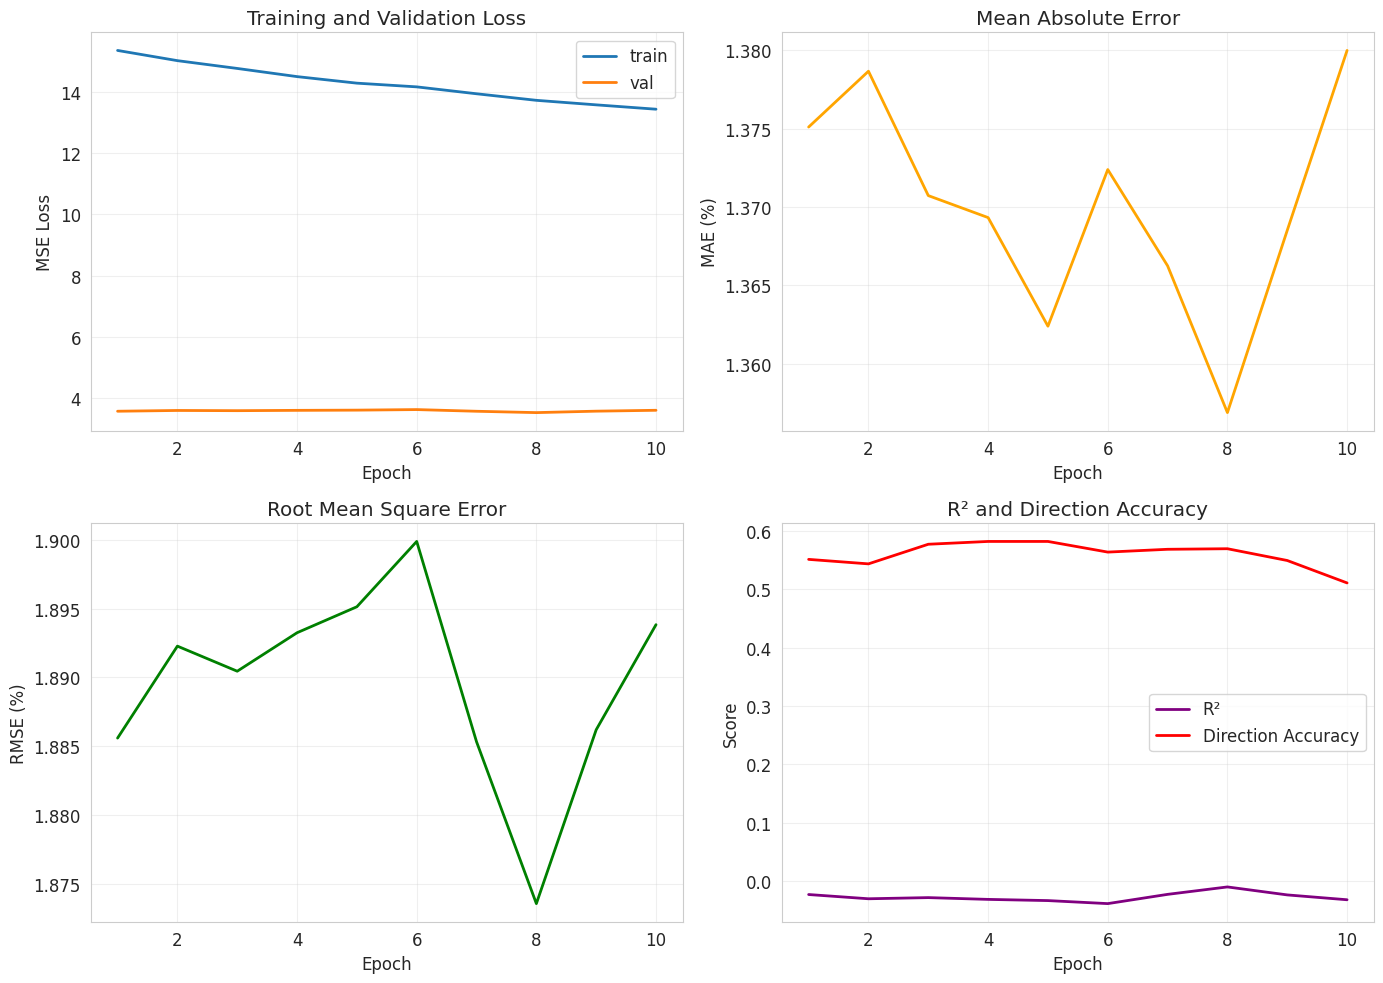


Epoch 10/10:
  Train Loss: 13.449021
  Val Loss:   3.586596
  MAE:  1.3800%
  RMSE: 1.8938%
  R²:   -0.0318
  Dir Acc: 0.5106


In [16]:
train_losses, val_losses, val_metrics = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=test_loader,
    num_epochs=NUM_EPOCHS
)

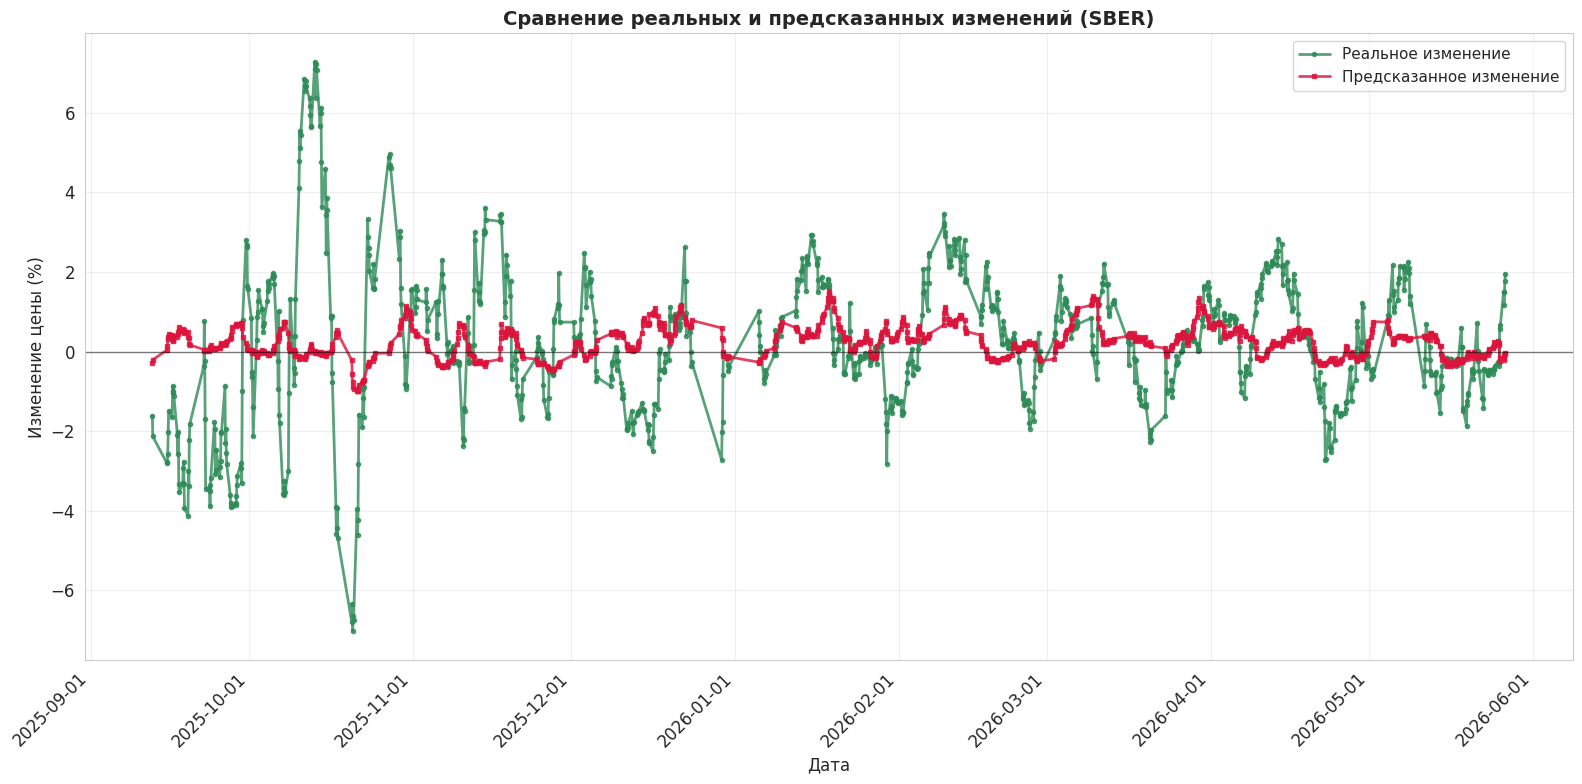

In [17]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for features, targets, lengths in test_loader:
        features = features.to(device)
        predictions = model(features, lengths.to(device))
        all_predictions.extend(predictions.cpu().numpy().flatten())
        all_targets.extend(targets.numpy().flatten())

final_metrics = calculate_metrics(np.array(all_targets), np.array(all_predictions))

results_df = pd.DataFrame({
    'begin': features_by_ticker['SBER'].iloc[-len(all_predictions):]['begin'].values,
    'target_price_change': all_targets,
    'predict': all_predictions
})

visualize_predictions_comparison(
    results_df, 
    title="Сравнение реальных и предсказанных изменений (SBER)"
)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'input_size': train_dataset.num_features,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_names': train_dataset.feature_names,
    'X_mean': train_dataset.X_mean,
    'X_std': train_dataset.X_std,
    'metrics': final_metrics
}

torch.save(checkpoint, 'lstm_stock_regressor_SBER.pt')

# Эксперименты

## Полный цикл обучения модели на примере SBER
- Подбор параметров с grid search
- Обучение лучшей модели
- Анализ ошибок модели

### Grid search

In [ ]:
import asyncio
import pandas as pd
from jupyter_utils import setup_jupyter_notebook

from stocks_dl.data.pipeline import (
    attach_tonality,
    build_features_by_ticker,
    load_candles_by_ticker,
    load_enrichments,
    merge_tonality_with_prices,
)
from stocks_dl.env_setup import suppress_mlflow_run_urls
from stocks_dl.workflows.experiment_runner import run_search, run_prd, select_best_row
from stocks_dl.workflows.error_analysis import run_error_analysis
from stocks_dl.viz.plotting import visualize_predictions_comparison

suppress_mlflow_run_urls()
TICKER = 'SBER'
SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.2
FINAL_VAL_SIZE = 0.15
BATCH_SIZE = 8
WEIGHT_DECAY = 0.01
BASE_EPOCHS = 8

<Experiment: artifact_location='s3://mlflow-bucket/mlflow/4', creation_time=1780513285993, experiment_id='4', last_update_time=1780513285993, lifecycle_stage='active', name='lstm_checkpoint', tags={}, trace_location=None, workspace='default'>

In [19]:
# Запускаем LSTM с grid search

from stocks_dl.data.pipeline import load_features_and_enrichments

features_df, enrichments_df = load_features_and_enrichments(TICKER)
summary_df = run_search(
    features_df=features_df,
    ticker=TICKER,
    experiment_name=EXPERIMENT_NAME,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    seed=SEED,
    batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    num_epochs=BASE_EPOCHS,
    show_plots=False,
)
summary_df.head(10)



Validating 1/8: 100%|██████████| 105/105 [00:00<00:00, 2184.93it/s]


Epoch 1/8: train=17.566255 val=7.727441 mae=2.2341% dir_acc=0.4868


Validating 2/8: 100%|██████████| 105/105 [00:00<00:00, 2205.98it/s]


Epoch 2/8: train=16.377711 val=7.972125 mae=2.2719% dir_acc=0.5024


Validating 3/8: 100%|██████████| 105/105 [00:00<00:00, 1801.57it/s]


...

Validating 7/8: 100%|██████████| 104/104 [00:00<00:00, 1661.48it/s]


Epoch 7/8: train=9.537818 val=9.452799 mae=2.5017% dir_acc=0.5240


Validating 8/8: 100%|██████████| 104/104 [00:00<00:00, 1687.95it/s]


Epoch 8/8: train=9.242232 val=8.872986 mae=2.3930% dir_acc=0.5204
🏃 View run sber_exp_50 at: http://localhost:5050/#/experiments/4/runs/4edab9481f574c8b89001b483a4cf982
🧪 View experiment at: http://localhost:5050/#/experiments/4


,run_id,run_name,ticker,sequence_length,hidden_size,num_layers,dropout,learning_rate,batch_size,num_epochs,...,train_direction_accuracy,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy,config_json
0,a332e883b56047b9911dd2be3599de5a,sber_exp_06,SBER,5,32,2,0.25,0.0004,8,8,...,0.776983,2.487080,3.058997,-0.201638,0.553828,1.882019,2.458976,-0.738365,0.503824,"{""run_name"": ""sber_exp_06"", ""ticker"": ""SBER"", ..."
1,a89bf69a9d7a49a9a6deab5d43d4ab0a,sber_exp_21,SBER,9,32,1,0.10,0.0006,8,8,...,0.780597,2.492946,3.118098,-0.250301,0.550481,2.406029,2.967847,-1.533964,0.495202,"{""run_name"": ""sber_exp_21"", ""ticker"": ""SBER"", ..."
2,9e6f20cce90f478cb06b680c0382baf7,sber_exp_42,SBER,7,32,3,0.35,0.0003,8,8,...,0.761337,2.459689,3.022790,-0.173906,0.549161,1.553199,2.117577,-0.290226,0.554598,"{""run_name"": ""sber_exp_42"", ""ticker"": ""SBER"", ..."
3,ecb15b3f1d6f4874bd9201fad82f241c,sber_exp_10,SBER,7,8,2,0.25,0.0004,8,8,...,0.783711,2.293870,2.863277,-0.053280,0.546763,1.760969,2.193143,-0.383954,0.574713,"{""run_name"": ""sber_exp_10"", ""ticker"": ""SBER"", ..."
4,8e30ac07d7bb449ba04bdcbabf7a5f94,sber_exp_39,SBER,16,64,1,0.15,0.0004,8,8,...,0.819324,2.545002,3.164915,-0.282113,0.546667,2.251525,2.794484,-1.258321,0.499517,"{""run_name"": ""sber_exp_39"", ""ticker"": ""SBER"", ..."
5,66a8ee8eba41469d828fd4aa0ef5d731,sber_exp_36,SBER,16,16,2,0.25,0.0004,8,8,...,0.811846,2.358578,2.969635,-0.128778,0.541818,1.950655,2.443728,-0.726984,0.537198,"{""run_name"": ""sber_exp_36"", ""ticker"": ""SBER"", ..."
6,1477da1c687d4bee9f9e55cb5be38492,sber_exp_09,SBER,7,8,1,0.10,0.0006,8,8,...,0.752088,2.355654,2.945027,-0.114284,0.538369,1.478904,2.004853,-0.156519,0.561303,"{""run_name"": ""sber_exp_09"", ""ticker"": ""SBER"", ..."
7,9b4c2138a5da4edb8afa57f185cd5636,sber_exp_33,SBER,16,8,1,0.10,0.0006,8,8,...,0.798983,2.486995,3.090312,-0.222382,0.538182,1.793580,2.302661,-0.533354,0.540097,"{""run_name"": ""sber_exp_33"", ""ticker"": ""SBER"", ..."
8,6208d43cbbda463cbbc6cfe7923d6165,sber_exp_12,SBER,7,16,2,0.25,0.0004,8,8,...,0.792363,2.367551,2.955634,-0.122325,0.535971,1.589626,2.091209,-0.258296,0.551724,"{""run_name"": ""sber_exp_12"", ""ticker"": ""SBER"", ..."
9,d53bd59e6b7e4cd09f581db269858b94,sber_exp_47,SBER,9,32,3,0.35,0.0003,8,8,...,0.793731,2.362300,2.940849,-0.112194,0.534856,1.817725,2.372460,-0.619256,0.532630,"{""run_name"": ""sber_exp_47"", ""ticker"": ""SBER"", ..."


### Обучение лучшей модели

In [20]:
# PRD: переобучение лучшей конфигурации + тег PRD + demo CSV
# CLI: uv run python -m stocks_dl.cli.dl_experiments mode=prd environment=prod

best_row = select_best_row(summary_df)
print('Best:', best_row['run_name'], 'val_dir_acc=', best_row['val_direction_accuracy'])

prd_run_summary, prd_run_id, prd_train_df, prd_val_df, test_df = run_prd(
    features_df=features_df,
    summary_df=summary_df,
    experiment_name=EXPERIMENT_NAME,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    final_val_size=FINAL_VAL_SIZE,
    seed=SEED,
    show_plots=False,
)
print('PRD run_id:', prd_run_id)
prd_run_summary



Best: sber_exp_06 val_dir_acc= 0.5538277511961722


Validating 1/8: 100%|██████████| 79/79 [00:00<00:00, 1909.02it/s]


Epoch 1/8: train=16.944448 val=5.501070 mae=1.8634% dir_acc=0.5048


Validating 2/8: 100%|██████████| 79/79 [00:00<00:00, 1952.36it/s]


Epoch 2/8: train=14.689693 val=6.040459 mae=1.9422% dir_acc=0.5096


...

Validating 8/8: 100%|██████████| 79/79 [00:00<00:00, 1854.85it/s]


Epoch 8/8: train=9.976805 val=9.511556 mae=2.5119% dir_acc=0.4872


2026/06/03 23:17:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/03 23:17:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/03 23:18:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/03 23:18:00 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/03 23:18:00 INFO mlflow.utils.environment: Detected uv project at /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor. Attempting to export requirements via 'uv export'.
2026/06/03 2

🏃 View run sber_prd_sber_exp_06 at: http://localhost:5050/#/experiments/4/runs/81ef481d37b54920a5f006a71fbf4caf
🧪 View experiment at: http://localhost:5050/#/experiments/4
PRD run_id: 81ef481d37b54920a5f006a71fbf4caf


{'run_id': '81ef481d37b54920a5f006a71fbf4caf',
 'run_name': 'sber_prd_sber_exp_06',
 'ticker': 'SBER',
 'sequence_length': 5,
 'hidden_size': 32,
 'num_layers': 2,
 'dropout': 0.25,
 'learning_rate': 0.0004,
 'batch_size': 8,
 'num_epochs': 8,
 'seed': 42,
 'train_mae': 2.019141674041748,
 'train_rmse': 3.0339245796203613,
 'train_r2': 0.47051525115966797,
 'train_direction_accuracy': 0.7783389450056116,
 'val_mae': 2.5118508338928223,
 'val_rmse': 3.084080934524536,
 'val_r2': -0.7229834794998169,
 'val_direction_accuracy': 0.48722044728434505,
 'test_mae': 1.5463413000106812,
 'test_rmse': 2.104422092437744,
 'test_r2': -0.2732044458389282,
 'test_direction_accuracy': 0.5544933078393881,
 'config_json': '{"run_name": "sber_prd_sber_exp_06", "ticker": "SBER", "seed": 42, "sequence_length": 5, "hidden_size": 32, "num_layers": 2, "dropout": 0.25, "learning_rate": 0.0004, "batch_size": 8, "weight_decay": 0.01, "num_epochs": 8}',
 'best_search_run_id': 'a332e883b56047b9911dd2be3599de5a',


### Анализ ошибок

🏃 View run SBER_analysis at: http://localhost:5050/#/experiments/4/runs/0c8db1d892c24735a9001c7954eadeeb
🧪 View experiment at: http://localhost:5050/#/experiments/4


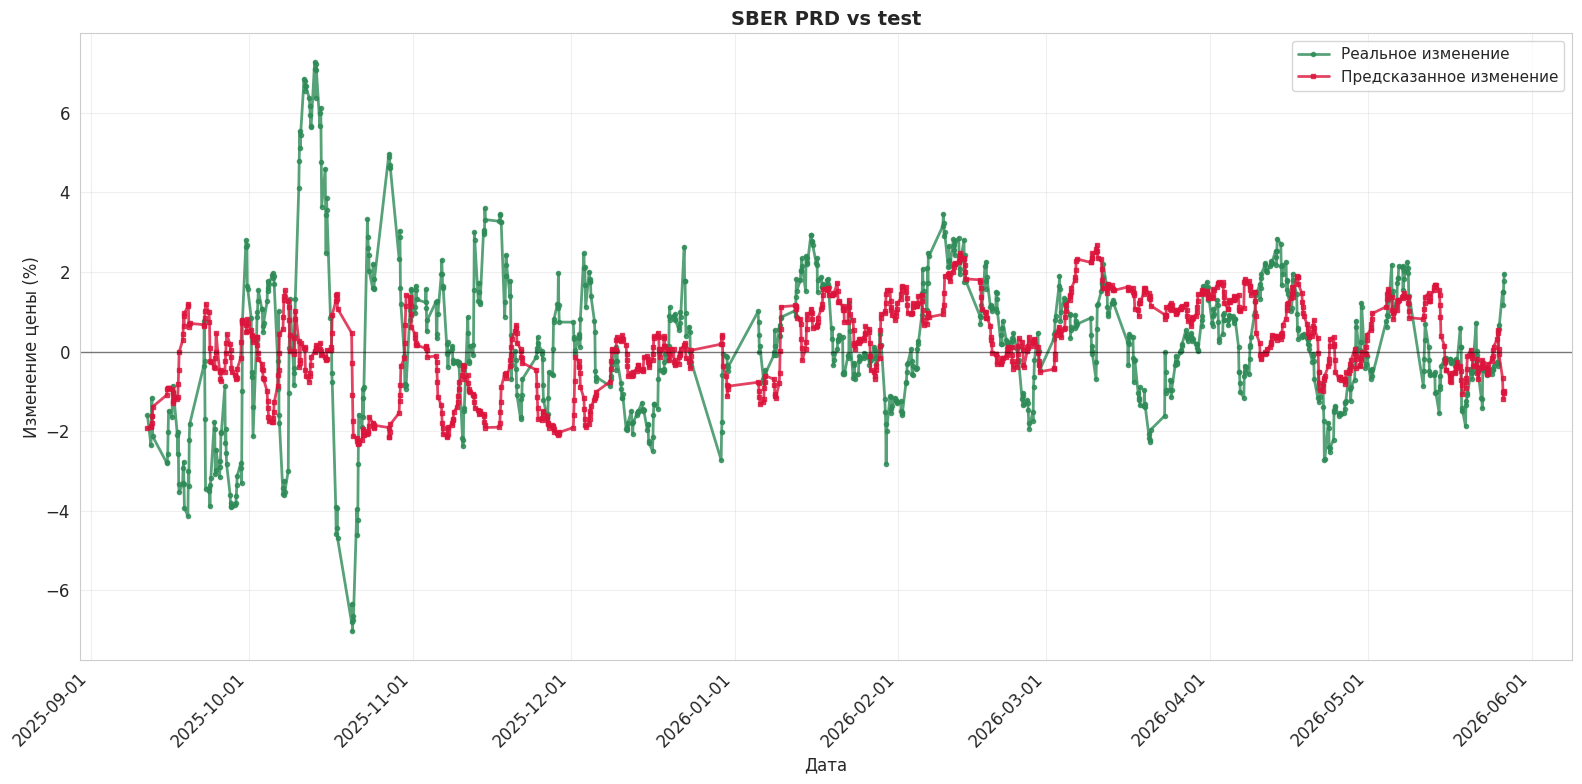

,model_mae,model_rmse,model_r2,model_direction_accuracy,baseline_mae,baseline_rmse,baseline_r2,baseline_direction_accuracy
0,1.546368,2.104444,-0.273231,0.554493,1.380811,1.877478,-0.013402,0.465583


In [ ]:
analysis = run_error_analysis(
    prd_run_id=prd_run_id,
    prd_run_summary=prd_run_summary,
    prd_train_df=prd_train_df,
    prd_val_df=prd_val_df,
    test_df=test_df,
    ticker=TICKER,
    enrichments_df=enrichments_df,
    experiment_name=EXPERIMENT_NAME,
)
visualize_predictions_comparison(analysis['predictions_df'], title=f'{TICKER} PRD vs test')
analysis['error_summary_df']



In [28]:

def prod_train_analyze(summary_df: pd.DataFrame):
    prd_run_summary, prd_run_id, prd_train_df, prd_val_df, test_df = run_prd(
        features_df=features_df,
        summary_df=summary_df,
        experiment_name=EXPERIMENT_NAME,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE,
        final_val_size=FINAL_VAL_SIZE,
        seed=SEED,
        show_plots=False,
    )
    print('PRD run_id:', prd_run_id)
    display(prd_run_summary)

    analysis = run_error_analysis(
        prd_run_id=prd_run_id,
        prd_run_summary=prd_run_summary,
        prd_train_df=prd_train_df,
        prd_val_df=prd_val_df,
        test_df=test_df,
        ticker=TICKER,
        enrichments_df=enrichments_df,
        experiment_name=EXPERIMENT_NAME,
    )
    visualize_predictions_comparison(analysis['predictions_df'], title=f'{TICKER} PRD vs test')
    display(analysis['error_summary_df'])



## Эксперименты GAZP

In [ ]:
from itertools import product

import pandas as pd

from stocks_dl.constants import TARGET_COLUMN
from stocks_dl.training.dataset import split_train_test
from stocks_dl.workflows.experiment_runner import run_experiment

def build_ticker_configs(ticker_name):
    configs_local = []
    depth_grid_main_local = list(product([5, 7, 9, 12, 16], [8, 16, 32, 64], [1, 2]))
    depth_grid_deep_local = list(product([7, 9], [16, 32, 64, 96, 128], [3]))
    full_grid_local = depth_grid_main_local + depth_grid_deep_local
    for idx_local, (sequence_length, hidden_size, num_layers) in enumerate(full_grid_local, start=1):
        if num_layers == 1:
            dropout = 0.10 if hidden_size <= 32 else 0.15
            learning_rate = 6e-4 if hidden_size <= 32 else 4e-4
        elif num_layers == 2:
            dropout = 0.25 if hidden_size <= 32 else 0.30
            learning_rate = 4e-4 if hidden_size <= 32 else 3e-4
        else:
            dropout = 0.35 if hidden_size <= 64 else 0.40
            learning_rate = 3e-4 if hidden_size <= 64 else 2e-4
        configs_local.append({
            'run_name': f'{ticker_name.lower()}_exp_{idx_local:02d}',
            'ticker': ticker_name,
            'seed': SEED,
            'sequence_length': sequence_length,
            'hidden_size': hidden_size,
            'num_layers': num_layers,
            'dropout': dropout,
            'learning_rate': learning_rate,
            'batch_size': BATCH_SIZE,
            'weight_decay': WEIGHT_DECAY,
            'num_epochs': BASE_EPOCHS,
        })
    return configs_local

def run_ticker_experiments(ticker_name):
    ticker_df = features_by_ticker[ticker_name].copy()
    ticker_train_df, ticker_val_df, ticker_test_df = split_train_test(
        ticker_df,
        target_column=TARGET_COLUMN,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE,
    )
    ticker_configs = build_ticker_configs(ticker_name)
    ticker_rows = []
    for cfg in ticker_configs:
        run_summary, run_id = run_experiment(
            cfg=cfg,
            train_df=ticker_train_df,
            val_df=ticker_val_df,
            test_df=ticker_test_df,
            stage='search',
            log_model=False,
        )
        ticker_rows.append(run_summary)
    ticker_summary_df = pd.DataFrame(ticker_rows).sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).reset_index(drop=True)
    ticker_summary_df.to_csv(f'{ticker_name.lower()}_search_summary.csv', index=False)
    return ticker_summary_df

gazp_summary_df = run_ticker_experiments('GAZP')
gazp_summary_df

Validating 1/8: 100%|██████████| 105/105 [00:00<00:00, 2180.07it/s]


Epoch 1/8: train=38.660871 val=36.979792 mae=4.8171% dir_acc=0.5658


Validating 2/8: 100%|██████████| 105/105 [00:00<00:00, 2237.99it/s]


Epoch 2/8: train=36.974209 val=36.623020 mae=4.7682% dir_acc=0.6136


Validating 3/8: 100%|██████████| 105/105 [00:00<00:00, 2148.45it/s]


...

Validating 7/8: 100%|██████████| 104/104 [00:00<00:00, 1489.52it/s]


Epoch 7/8: train=26.829863 val=36.310181 mae=4.7548% dir_acc=0.6154


Validating 8/8: 100%|██████████| 104/104 [00:00<00:00, 1660.87it/s]


Epoch 8/8: train=25.988696 val=38.362895 mae=4.8664% dir_acc=0.5841
🏃 View run gazp_exp_50 at: http://localhost:5050/#/experiments/4/runs/08fcc53219fa4b958319c12c8907c1e6
🧪 View experiment at: http://localhost:5050/#/experiments/4


,run_id,run_name,ticker,sequence_length,hidden_size,num_layers,dropout,learning_rate,batch_size,num_epochs,...,train_direction_accuracy,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy,config_json
0,79d79fd0148e49d99c50fe31d0bade58,gazp_exp_36,GAZP,16,16,2,0.25,0.0004,8,8,...,0.736165,4.557162,5.826052,0.076478,0.703030,3.108729,3.888699,-0.760678,0.533333,"{""run_name"": ""gazp_exp_36"", ""ticker"": ""GAZP"", ..."
1,160aafbdf5cf4ec1a566b746bdefefd7,gazp_exp_37,GAZP,16,32,1,0.10,0.0006,8,8,...,0.738259,4.885973,6.334053,-0.091595,0.677576,3.324889,4.120307,-0.976653,0.468599,"{""run_name"": ""gazp_exp_37"", ""ticker"": ""GAZP"", ..."
2,0ecdc077a1724f2fb0de6c071de372d3,gazp_exp_31,GAZP,12,64,1,0.15,0.0004,8,8,...,0.732298,5.260324,6.658358,-0.211659,0.661037,3.780036,4.689127,-1.553938,0.521655,"{""run_name"": ""gazp_exp_31"", ""ticker"": ""GAZP"", ..."
3,2ab4bc656a9b4d68bab03e3c89642a18,gazp_exp_04,GAZP,5,16,2,0.25,0.0004,8,8,...,0.698867,4.505678,5.750312,0.089363,0.651914,2.729487,3.441974,-0.367642,0.524857,"{""run_name"": ""gazp_exp_04"", ""ticker"": ""GAZP"", ..."
4,37b165f509024ed9a5e7e5d359412e5c,gazp_exp_39,GAZP,16,64,1,0.15,0.0004,8,8,...,0.760694,5.195963,6.640023,-0.199603,0.649697,3.586287,4.498763,-1.356446,0.464734,"{""run_name"": ""gazp_exp_39"", ""ticker"": ""GAZP"", ..."
5,75c4b5a3a91c4ce2bdc386effdb99e2f,gazp_exp_15,GAZP,7,64,1,0.15,0.0004,8,8,...,0.691826,4.796360,6.106892,-0.024707,0.645084,3.317701,4.104259,-0.952566,0.501916,"{""run_name"": ""gazp_exp_15"", ""ticker"": ""GAZP"", ..."
6,e07f5efaeae14a2884b8ae4eb354870b,gazp_exp_48,GAZP,9,64,3,0.35,0.0003,8,8,...,0.683582,4.741299,6.021036,0.006131,0.643029,3.035697,3.779079,-0.657400,0.495202,"{""run_name"": ""gazp_exp_48"", ""ticker"": ""GAZP"", ..."
7,ddf58aec3f794f79a87894ef97e681da,gazp_exp_28,GAZP,12,16,2,0.25,0.0004,8,8,...,0.718255,4.789180,6.120656,-0.023863,0.642943,3.130367,3.863307,-0.733583,0.538980,"{""run_name"": ""gazp_exp_28"", ""ticker"": ""GAZP"", ..."
8,d8e592fd7f334d4a8fe78f6c296271da,gazp_exp_21,GAZP,9,32,1,0.10,0.0006,8,8,...,0.738507,5.033675,6.357869,-0.108179,0.639423,3.413071,4.281807,-1.127695,0.514395,"{""run_name"": ""gazp_exp_21"", ""ticker"": ""GAZP"", ..."
9,4bcca44b925e4bef888e476d8a84ad2d,gazp_exp_30,GAZP,12,32,2,0.25,0.0004,8,8,...,0.738572,4.841790,6.262762,-0.071958,0.632087,3.117631,3.859245,-0.729939,0.532243,"{""run_name"": ""gazp_exp_30"", ""ticker"": ""GAZP"", ..."


Validating 1/8: 100%|██████████| 77/77 [00:00<00:00, 871.45it/s]


Epoch 1/8: train=17.431079 val=5.510726 mae=1.8734% dir_acc=0.4504


Validating 2/8: 100%|██████████| 77/77 [00:00<00:00, 1688.36it/s]


Epoch 2/8: train=14.717660 val=5.890154 mae=1.9260% dir_acc=0.4927


Validating 3/8: 100%|██████████| 77/77 [00:00<00:00, 1536.67it/s]


...

Epoch 8/8: train=9.001026 val=8.153854 mae=2.2679% dir_acc=0.4927


2026/06/04 00:15:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:15:15 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:15:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/04 00:15:17 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:15:17 INFO mlflow.utils.environment: Detected uv project at /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor. Attempting to export requirements via 'uv export'.
2026/06/04 0

🏃 View run gazp_prd_gazp_exp_36 at: http://localhost:5050/#/experiments/4/runs/fe645b594c794440a6d01ce05653b3f3
🧪 View experiment at: http://localhost:5050/#/experiments/4
PRD run_id: fe645b594c794440a6d01ce05653b3f3


{'run_id': 'fe645b594c794440a6d01ce05653b3f3',
 'run_name': 'gazp_prd_gazp_exp_36',
 'ticker': 'GAZP',
 'sequence_length': 16,
 'hidden_size': 16,
 'num_layers': 2,
 'dropout': 0.25,
 'learning_rate': 0.0004,
 'batch_size': 8,
 'num_epochs': 8,
 'seed': 42,
 'train_mae': 1.9140567779541016,
 'train_rmse': 2.920048713684082,
 'train_r2': 0.5109672546386719,
 'train_direction_accuracy': 0.8139600337742753,
 'val_mae': 2.267949104309082,
 'val_rmse': 2.8554954528808594,
 'val_r2': -0.5425983667373657,
 'val_direction_accuracy': 0.4926829268292683,
 'test_mae': 1.9796785116195679,
 'test_rmse': 2.4505956172943115,
 'test_r2': -0.7367039918899536,
 'test_direction_accuracy': 0.5323671497584541,
 'config_json': '{"run_name": "gazp_prd_gazp_exp_36", "ticker": "GAZP", "seed": 42, "sequence_length": 16, "hidden_size": 16, "num_layers": 2, "dropout": 0.25, "learning_rate": 0.0004, "batch_size": 8, "weight_decay": 0.01, "num_epochs": 8}',
 'best_search_run_id': '79d79fd0148e49d99c50fe31d0bade58',

🏃 View run SBER_analysis at: http://localhost:5050/#/experiments/4/runs/1aae3c68545748a1a46e66b607638997
🧪 View experiment at: http://localhost:5050/#/experiments/4


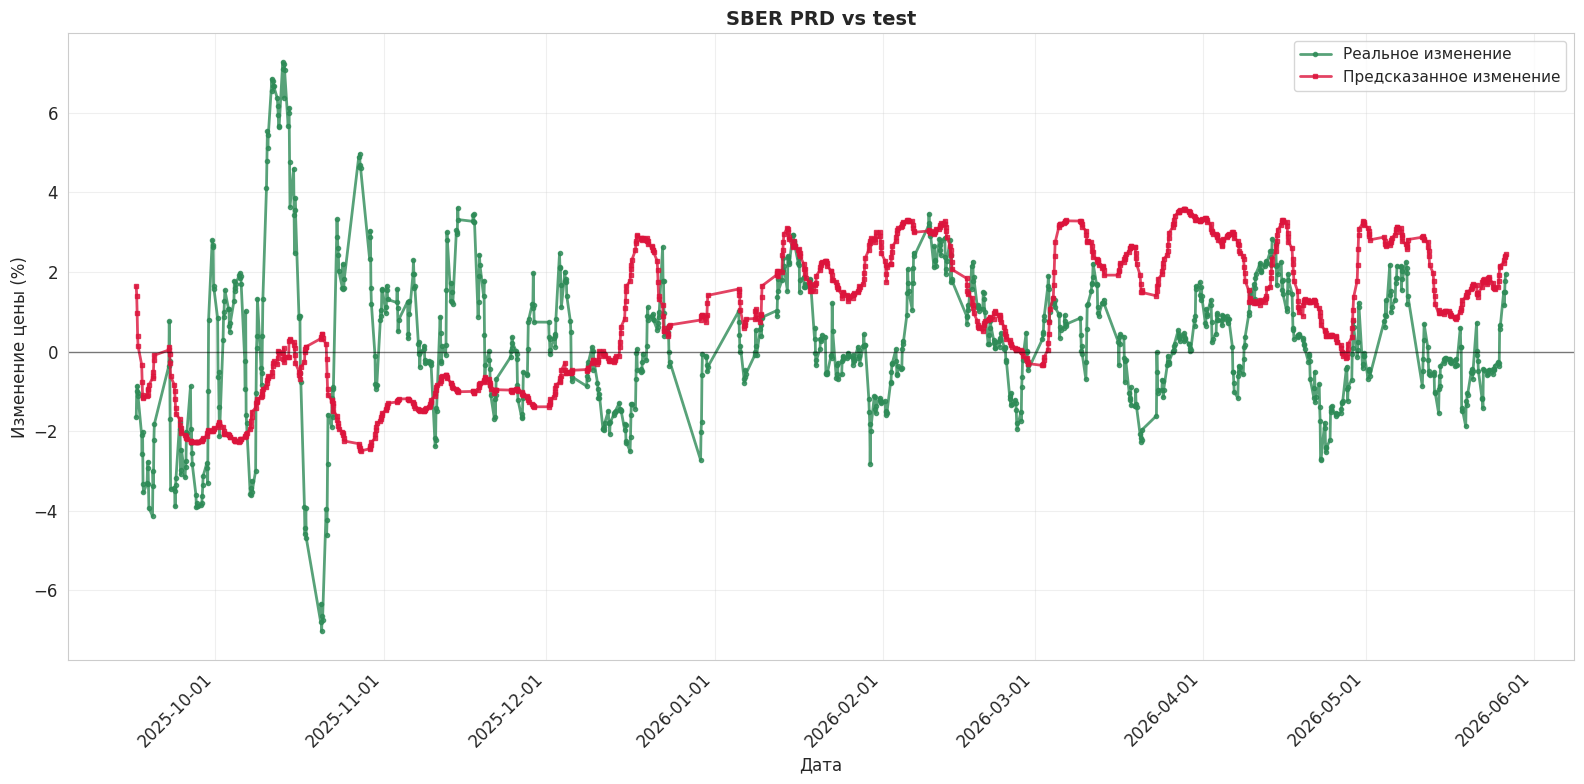

,model_mae,model_rmse,model_r2,model_direction_accuracy,baseline_mae,baseline_rmse,baseline_r2,baseline_direction_accuracy
0,1.979649,2.450571,-0.736669,0.532367,1.373851,1.874957,-0.016635,0.459903


In [29]:
prod_train_analyze(gazp_summary_df)

## Эксперименты LKOH

In [24]:
lkoh_summary_df = run_ticker_experiments('LKOH')
lkoh_summary_df

Validating 1/8: 100%|██████████| 105/105 [00:00<00:00, 2176.58it/s]


Epoch 1/8: train=13.953243 val=12.434092 mae=2.7814% dir_acc=0.6053


Validating 2/8: 100%|██████████| 105/105 [00:00<00:00, 2140.21it/s]


Epoch 2/8: train=13.056871 val=12.426830 mae=2.7792% dir_acc=0.6053


Validating 3/8: 100%|██████████| 105/105 [00:00<00:00, 2365.31it/s]


...

Validating 7/8: 100%|██████████| 104/104 [00:00<00:00, 1270.12it/s]


Epoch 7/8: train=8.225836 val=13.513108 mae=3.0153% dir_acc=0.5913


Validating 8/8: 100%|██████████| 104/104 [00:00<00:00, 1130.67it/s]


Epoch 8/8: train=7.879480 val=12.724664 mae=2.8927% dir_acc=0.5865
🏃 View run lkoh_exp_50 at: http://localhost:5050/#/experiments/4/runs/7d412346ff4e46349f66f3d5c508894e
🧪 View experiment at: http://localhost:5050/#/experiments/4


,run_id,run_name,ticker,sequence_length,hidden_size,num_layers,dropout,learning_rate,batch_size,num_epochs,...,train_direction_accuracy,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy,config_json
0,08da8cae5c004c3c85cffaa47b7d1e15,lkoh_exp_18,LKOH,9,8,2,0.25,0.0004,8,8,...,0.800299,2.885107,3.534187,0.017718,0.637019,3.387702,4.527504,-0.308832,0.476967,"{""run_name"": ""lkoh_exp_18"", ""ticker"": ""LKOH"", ..."
1,2bb7b83ba05c4389900148096a85628d,lkoh_exp_10,LKOH,7,8,2,0.25,0.0004,8,8,...,0.795644,2.901926,3.547352,0.011479,0.633094,3.382944,4.559519,-0.328954,0.475096,"{""run_name"": ""lkoh_exp_10"", ""ticker"": ""LKOH"", ..."
2,3fc1768bc7bf436b9fa6506c3423509f,lkoh_exp_41,LKOH,7,16,3,0.35,0.0003,8,8,...,0.769391,2.805549,3.480656,0.048301,0.630695,3.238096,4.339757,-0.203935,0.498084,"{""run_name"": ""lkoh_exp_41"", ""ticker"": ""LKOH"", ..."
3,2ef9dae00f134d36a6269fc205b8da34,lkoh_exp_48,LKOH,9,64,3,0.35,0.0003,8,8,...,0.789851,2.899635,3.505533,0.033582,0.625000,3.519826,4.602834,-0.352747,0.438580,"{""run_name"": ""lkoh_exp_48"", ""ticker"": ""LKOH"", ..."
4,7a145793f1a940e38f88400b6bbd67ab,lkoh_exp_22,LKOH,9,32,2,0.25,0.0004,8,8,...,0.814328,2.823788,3.552393,0.007572,0.617788,3.896374,4.885281,-0.523860,0.432821,"{""run_name"": ""lkoh_exp_22"", ""ticker"": ""LKOH"", ..."
5,5aa8963e8fc84263a00398e52e8da3e9,lkoh_exp_26,LKOH,12,8,2,0.25,0.0004,8,8,...,0.795040,2.929149,3.603603,-0.022621,0.612786,3.471208,4.593331,-0.344644,0.487969,"{""run_name"": ""lkoh_exp_26"", ""ticker"": ""LKOH"", ..."
6,01c8f34602b245bf920c888ef27f173e,lkoh_exp_14,LKOH,7,32,2,0.25,0.0004,8,8,...,0.803998,2.897887,3.570127,-0.001255,0.612710,3.631051,4.742911,-0.438010,0.439655,"{""run_name"": ""lkoh_exp_14"", ""ticker"": ""LKOH"", ..."
7,ca8c6923d4124996b7e5154662bdbb62,lkoh_exp_37,LKOH,16,32,1,0.10,0.0006,8,8,...,0.820520,2.922632,3.687291,-0.075930,0.608485,3.816611,4.837861,-0.489072,0.457971,"{""run_name"": ""lkoh_exp_37"", ""ticker"": ""LKOH"", ..."
8,34a03317f0f4462b810bfaf3124998ef,lkoh_exp_42,LKOH,7,32,3,0.35,0.0003,8,8,...,0.784010,2.958593,3.619913,-0.029376,0.606715,3.534503,4.683545,-0.402237,0.453065,"{""run_name"": ""lkoh_exp_42"", ""ticker"": ""LKOH"", ..."
9,cffc7bd787f94c20990618c6600038c5,lkoh_exp_07,LKOH,5,64,1,0.15,0.0004,8,8,...,0.765057,2.813933,3.478654,0.048948,0.604067,3.459953,4.491776,-0.290555,0.458891,"{""run_name"": ""lkoh_exp_07"", ""ticker"": ""LKOH"", ..."


Validating 1/8: 100%|██████████| 78/78 [00:00<00:00, 1776.15it/s]


Epoch 1/8: train=17.458052 val=5.638017 mae=1.8888% dir_acc=0.5177


Validating 2/8: 100%|██████████| 78/78 [00:00<00:00, 1762.12it/s]


Epoch 2/8: train=16.208843 val=5.895756 mae=1.9150% dir_acc=0.4904


Validating 3/8: 100%|██████████| 78/78 [00:00<00:00, 1815.32it/s]


...

Epoch 8/8: train=10.950504 val=8.016953 mae=2.2101% dir_acc=0.4855


2026/06/04 00:15:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:15:35 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:15:36 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/04 00:15:36 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:15:36 INFO mlflow.utils.environment: Detected uv project at /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor. Attempting to export requirements via 'uv export'.
2026/06/04 0

🏃 View run lkoh_prd_lkoh_exp_18 at: http://localhost:5050/#/experiments/4/runs/0b64304d3ff7495f983c5f9e9613246a
🧪 View experiment at: http://localhost:5050/#/experiments/4
PRD run_id: 0b64304d3ff7495f983c5f9e9613246a


{'run_id': '0b64304d3ff7495f983c5f9e9613246a',
 'run_name': 'lkoh_prd_lkoh_exp_18',
 'ticker': 'LKOH',
 'sequence_length': 9,
 'hidden_size': 8,
 'num_layers': 2,
 'dropout': 0.25,
 'learning_rate': 0.0004,
 'batch_size': 8,
 'num_epochs': 8,
 'seed': 42,
 'train_mae': 2.109189033508301,
 'train_rmse': 3.1879172325134277,
 'train_r2': 0.4160340428352356,
 'train_direction_accuracy': 0.803932584269663,
 'val_mae': 2.2100555896759033,
 'val_rmse': 2.8314225673675537,
 'val_r2': -0.46066391468048096,
 'val_direction_accuracy': 0.4855305466237942,
 'test_mae': 1.8991858959197998,
 'test_rmse': 2.354275703430176,
 'test_r2': -0.5945279598236084,
 'test_direction_accuracy': 0.5623800383877159,
 'config_json': '{"run_name": "lkoh_prd_lkoh_exp_18", "ticker": "LKOH", "seed": 42, "sequence_length": 9, "hidden_size": 8, "num_layers": 2, "dropout": 0.25, "learning_rate": 0.0004, "batch_size": 8, "weight_decay": 0.01, "num_epochs": 8}',
 'best_search_run_id': '08da8cae5c004c3c85cffaa47b7d1e15',
 'b

🏃 View run SBER_analysis at: http://localhost:5050/#/experiments/4/runs/f3c666faa8a04dc9a007c1acd8d179c6
🧪 View experiment at: http://localhost:5050/#/experiments/4


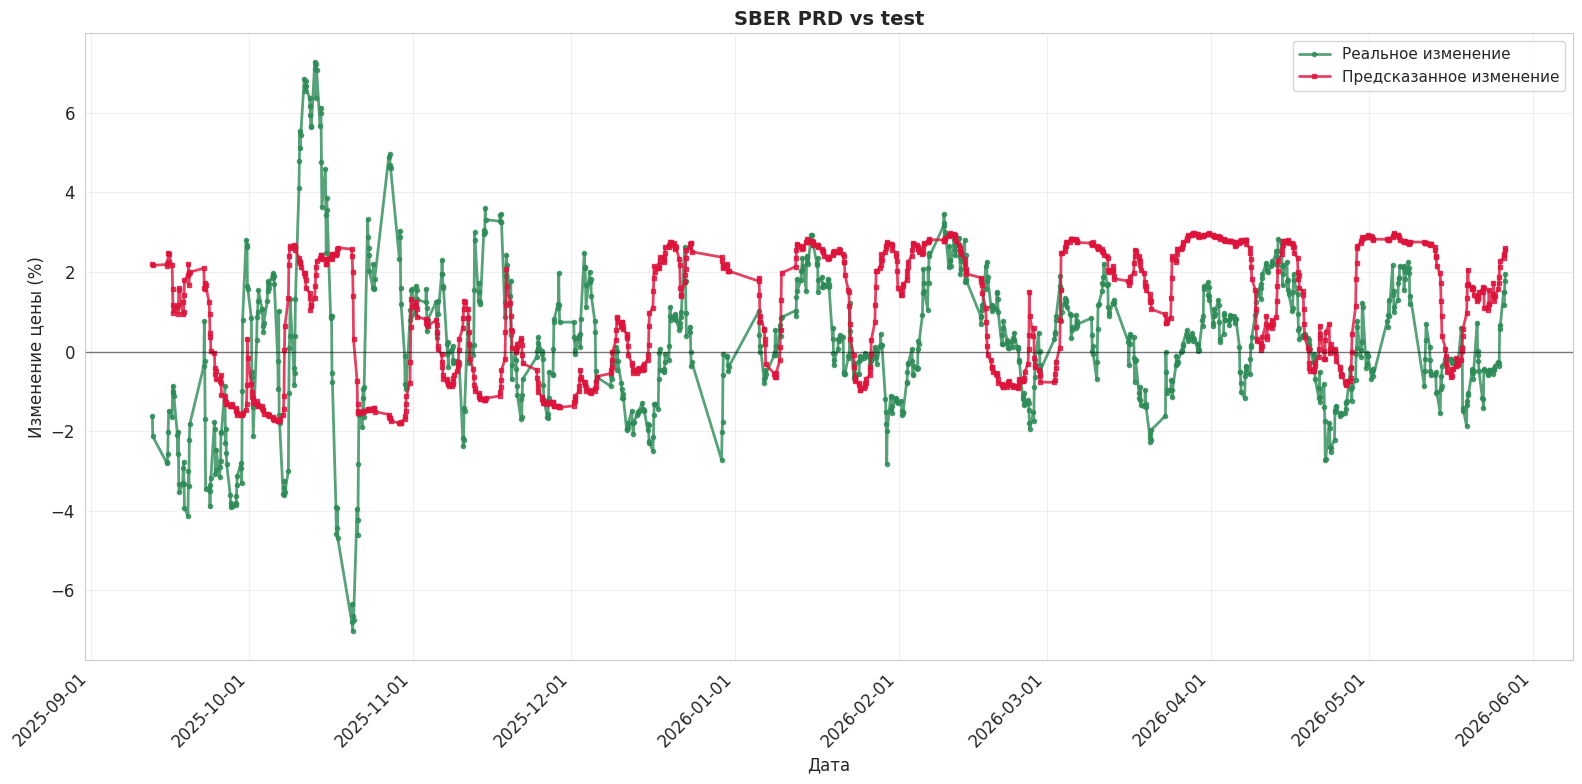

,model_mae,model_rmse,model_r2,model_direction_accuracy,baseline_mae,baseline_rmse,baseline_r2,baseline_direction_accuracy
0,1.899099,2.354176,-0.594393,0.56238,1.379391,1.877753,-0.014365,0.463532


In [30]:
prod_train_analyze(lkoh_summary_df)

## Эксперименты ROSN

In [25]:
rosn_summary_df = run_ticker_experiments('ROSN')
rosn_summary_df

Validating 1/8: 100%|██████████| 105/105 [00:00<00:00, 2109.47it/s]


Epoch 1/8: train=19.498611 val=20.492771 mae=3.5861% dir_acc=0.5921


Validating 2/8: 100%|██████████| 105/105 [00:00<00:00, 1934.79it/s]


Epoch 2/8: train=18.438828 val=20.547492 mae=3.5904% dir_acc=0.6435


Validating 3/8: 100%|██████████| 105/105 [00:00<00:00, 2004.69it/s]


...

Validating 7/8: 100%|██████████| 104/104 [00:00<00:00, 1683.49it/s]


Epoch 7/8: train=11.954801 val=25.903235 mae=3.8240% dir_acc=0.5853


Validating 8/8: 100%|██████████| 104/104 [00:00<00:00, 741.10it/s]


Epoch 8/8: train=11.506104 val=25.324074 mae=3.7788% dir_acc=0.5853
🏃 View run rosn_exp_50 at: http://localhost:5050/#/experiments/4/runs/00ada171b16744cbbf7196cd32874c97
🧪 View experiment at: http://localhost:5050/#/experiments/4


,run_id,run_name,ticker,sequence_length,hidden_size,num_layers,dropout,learning_rate,batch_size,num_epochs,...,train_direction_accuracy,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy,config_json
0,8ba1f479c1124deea1f5aa1736b8206b,rosn_exp_37,ROSN,16,32,1,0.10,0.0006,8,8,...,0.796291,3.623157,4.880632,-0.186721,0.661818,4.623208,5.512166,-0.870755,0.428986,"{""run_name"": ""rosn_exp_37"", ""ticker"": ""ROSN"", ..."
1,54304d73786243cab4b46a5da62c1969,rosn_exp_26,ROSN,12,8,2,0.25,0.0004,8,8,...,0.805199,3.489774,4.510297,-0.007277,0.657419,3.745908,4.823568,-0.436024,0.454283,"{""run_name"": ""rosn_exp_26"", ""ticker"": ""ROSN"", ..."
2,e72374c15eaa455d921b595f999f8275,rosn_exp_02,ROSN,5,8,2,0.25,0.0004,8,8,...,0.789207,3.406173,4.420247,0.029839,0.656699,3.620312,4.605542,-0.305733,0.473231,"{""run_name"": ""rosn_exp_02"", ""ticker"": ""ROSN"", ..."
3,fb26262b918e404ba8732ac504357ae2,rosn_exp_10,ROSN,7,8,2,0.25,0.0004,8,8,...,0.797136,3.480381,4.473622,0.007457,0.655875,3.569750,4.617308,-0.315571,0.489464,"{""run_name"": ""rosn_exp_10"", ""ticker"": ""ROSN"", ..."
4,ac0f64994d9f4252881fc0fa814e8775,rosn_exp_01,ROSN,5,8,1,0.10,0.0006,8,8,...,0.752832,3.552171,4.619857,-0.059761,0.650718,3.882445,4.888877,-0.471334,0.494264,"{""run_name"": ""rosn_exp_01"", ""ticker"": ""ROSN"", ..."
5,37f7e8136ef74075adf34407182b4c1c,rosn_exp_33,ROSN,16,8,1,0.10,0.0006,8,8,...,0.775651,3.493640,4.526503,-0.020757,0.644848,3.956437,5.007846,-0.544097,0.438647,"{""run_name"": ""rosn_exp_33"", ""ticker"": ""ROSN"", ..."
6,cc3b0abbf2fd4ceca4c85ac50927b3f8,rosn_exp_09,ROSN,7,8,1,0.10,0.0006,8,8,...,0.767601,3.476799,4.548756,-0.026163,0.642686,3.708895,4.741797,-0.387466,0.485632,"{""run_name"": ""rosn_exp_09"", ""ticker"": ""ROSN"", ..."
7,da6f4ae0f7bc402083856e92f3345107,rosn_exp_34,ROSN,16,8,2,0.25,0.0004,8,8,...,0.816333,3.527458,4.536552,-0.025294,0.641212,3.668881,4.832230,-0.437698,0.520773,"{""run_name"": ""rosn_exp_34"", ""ticker"": ""ROSN"", ..."
8,cd34c7cdbac1446c98b509c876bb8ed3,rosn_exp_18,ROSN,9,8,2,0.25,0.0004,8,8,...,0.795224,3.568094,4.523834,-0.014002,0.640625,3.790407,4.803090,-0.424416,0.456814,"{""run_name"": ""rosn_exp_18"", ""ticker"": ""ROSN"", ..."
9,f4828c6623014f4fbc961629c0c23c1d,rosn_exp_29,ROSN,12,32,1,0.10,0.0006,8,8,...,0.774425,3.809035,5.158987,-0.317855,0.616405,4.348678,5.301604,-0.734761,0.423484,"{""run_name"": ""rosn_exp_29"", ""ticker"": ""ROSN"", ..."


Validating 1/8: 100%|██████████| 77/77 [00:00<00:00, 1430.89it/s]


Epoch 1/8: train=16.162155 val=5.685134 mae=1.8794% dir_acc=0.4959


Validating 2/8: 100%|██████████| 77/77 [00:00<00:00, 757.65it/s]


Epoch 2/8: train=12.649520 val=6.406661 mae=1.9892% dir_acc=0.5008


Validating 3/8: 100%|██████████| 77/77 [00:00<00:00, 1556.32it/s]


...

Epoch 8/8: train=7.269399 val=11.444717 mae=2.7200% dir_acc=0.5350


2026/06/04 00:15:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:15:49 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:15:50 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/04 00:15:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:15:50 INFO mlflow.utils.environment: Detected uv project at /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor. Attempting to export requirements via 'uv export'.
2026/06/04 0

🏃 View run rosn_prd_rosn_exp_37 at: http://localhost:5050/#/experiments/4/runs/9aad2b7af49f42e586a82a16a5aa566c
🧪 View experiment at: http://localhost:5050/#/experiments/4
PRD run_id: 9aad2b7af49f42e586a82a16a5aa566c


{'run_id': '9aad2b7af49f42e586a82a16a5aa566c',
 'run_name': 'rosn_prd_rosn_exp_37',
 'ticker': 'ROSN',
 'sequence_length': 16,
 'hidden_size': 32,
 'num_layers': 1,
 'dropout': 0.1,
 'learning_rate': 0.0006,
 'batch_size': 8,
 'num_epochs': 8,
 'seed': 42,
 'train_mae': 1.977337121963501,
 'train_rmse': 2.8573250770568848,
 'train_r2': 0.5317507982254028,
 'train_direction_accuracy': 0.7844075429214749,
 'val_mae': 2.7200050354003906,
 'val_rmse': 3.3830039501190186,
 'val_r2': -1.165184736251831,
 'val_direction_accuracy': 0.5349593495934959,
 'test_mae': 1.669189691543579,
 'test_rmse': 2.3488402366638184,
 'test_r2': -0.595473051071167,
 'test_direction_accuracy': 0.5391304347826087,
 'config_json': '{"run_name": "rosn_prd_rosn_exp_37", "ticker": "ROSN", "seed": 42, "sequence_length": 16, "hidden_size": 32, "num_layers": 1, "dropout": 0.1, "learning_rate": 0.0006, "batch_size": 8, "weight_decay": 0.01, "num_epochs": 8}',
 'best_search_run_id': '8ba1f479c1124deea1f5aa1736b8206b',
 'b

🏃 View run SBER_analysis at: http://localhost:5050/#/experiments/4/runs/53adf9dc80374f42a75ce729b65d7b29
🧪 View experiment at: http://localhost:5050/#/experiments/4


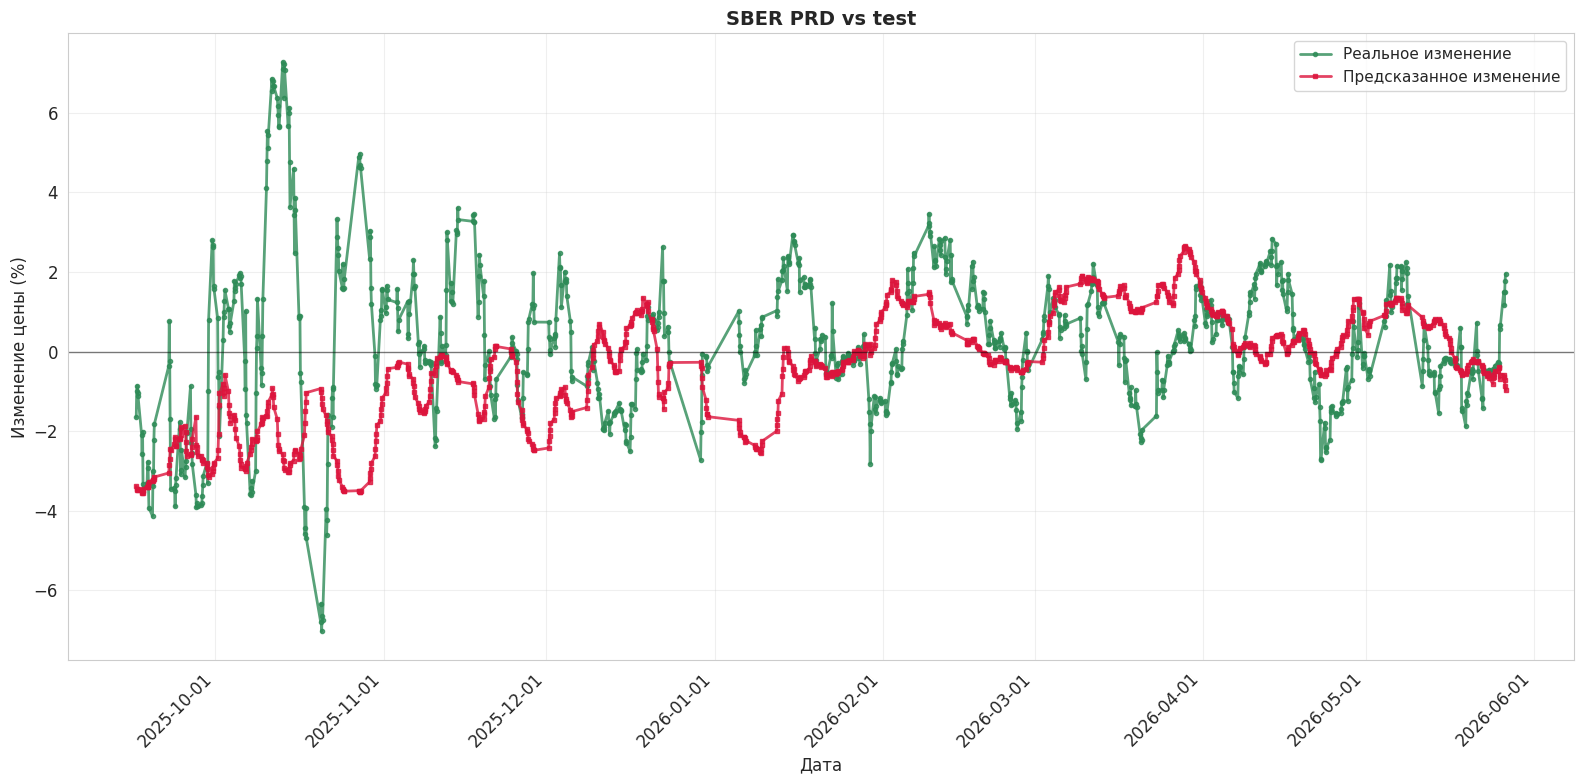

,model_mae,model_rmse,model_r2,model_direction_accuracy,baseline_mae,baseline_rmse,baseline_r2,baseline_direction_accuracy
0,1.669184,2.348824,-0.59545,0.53913,1.373851,1.874957,-0.016635,0.459903


In [31]:
prod_train_analyze(rosn_summary_df)

## Эксперименты TCSG

In [26]:
tcsg_summary_df = run_ticker_experiments('TCSG')
tcsg_summary_df

Validating 1/8: 100%|██████████| 57/57 [00:00<00:00, 1183.80it/s]


Epoch 1/8: train=34.538951 val=8.409435 mae=2.2924% dir_acc=0.6689


Validating 2/8: 100%|██████████| 57/57 [00:00<00:00, 2136.68it/s]


Epoch 2/8: train=33.303049 val=8.068429 mae=2.2441% dir_acc=0.6932


Validating 3/8: 100%|██████████| 57/57 [00:00<00:00, 2222.63it/s]


...

Validating 7/8: 100%|██████████| 57/57 [00:00<00:00, 1696.21it/s]


Epoch 7/8: train=17.794227 val=7.729115 mae=2.1684% dir_acc=0.6615


Validating 8/8: 100%|██████████| 57/57 [00:00<00:00, 1692.42it/s]


Epoch 8/8: train=16.626205 val=8.467752 mae=2.2836% dir_acc=0.6503
🏃 View run tcsg_exp_50 at: http://localhost:5050/#/experiments/4/runs/496a7b3ef7cc4c878aea7c6687bad29e
🧪 View experiment at: http://localhost:5050/#/experiments/4


,run_id,run_name,ticker,sequence_length,hidden_size,num_layers,dropout,learning_rate,batch_size,num_epochs,...,train_direction_accuracy,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy,config_json
0,48799a1d69c3407e8e2feaab003a968e,tcsg_exp_20,TCSG,9,16,2,0.25,0.0004,8,8,...,0.763346,2.065471,2.602831,0.226310,0.694878,3.987175,5.063922,-0.081581,0.504440,"{""run_name"": ""tcsg_exp_20"", ""ticker"": ""TCSG"", ..."
1,ab892a450ce44933967c8f9e84aeff75,tcsg_exp_49,TCSG,9,96,3,0.40,0.0002,8,8,...,0.760594,2.233902,2.857902,0.067240,0.694878,4.259233,5.319686,-0.193595,0.492007,"{""run_name"": ""tcsg_exp_49"", ""ticker"": ""TCSG"", ..."
2,ddcae72ec5eb416b9251318712278e6d,tcsg_exp_41,TCSG,7,16,3,0.35,0.0003,8,8,...,0.738868,2.054033,2.597817,0.226328,0.689579,3.929479,4.951779,-0.037513,0.522124,"{""run_name"": ""tcsg_exp_41"", ""ticker"": ""TCSG"", ..."
3,81ae4dc17ba94f8783e5cfc5c3107f5f,tcsg_exp_03,TCSG,5,16,1,0.10,0.0006,8,8,...,0.747392,2.277063,2.859399,0.060264,0.686534,3.830496,4.874730,-0.008961,0.529101,"{""run_name"": ""tcsg_exp_03"", ""ticker"": ""TCSG"", ..."
4,801b20f300c34dbaa2fe42e75cec8f59,tcsg_exp_42,TCSG,7,32,3,0.35,0.0003,8,8,...,0.777900,2.136504,2.701336,0.163440,0.682927,3.957193,5.010406,-0.062226,0.536283,"{""run_name"": ""tcsg_exp_42"", ""ticker"": ""TCSG"", ..."
5,8482abbab1a544e1851070bd4f06d3a9,tcsg_exp_45,TCSG,7,128,3,0.40,0.0002,8,8,...,0.763606,2.181399,2.776278,0.116380,0.676275,4.361192,5.392834,-0.230567,0.437168,"{""run_name"": ""tcsg_exp_45"", ""ticker"": ""TCSG"", ..."
6,f735cf3fb1d949188431c339c914e4d5,tcsg_exp_04,TCSG,5,16,2,0.25,0.0004,8,8,...,0.755080,2.088456,2.622279,0.209659,0.671082,3.984720,5.044000,-0.080248,0.465608,"{""run_name"": ""tcsg_exp_04"", ""ticker"": ""TCSG"", ..."
7,5aa789453a864605aec312fff79f2eb9,tcsg_exp_21,TCSG,9,32,1,0.10,0.0006,8,8,...,0.736379,2.200197,2.796007,0.107205,0.668151,4.094001,5.123922,-0.107363,0.467140,"{""run_name"": ""tcsg_exp_21"", ""ticker"": ""TCSG"", ..."
8,719ce7afabe24e9ba98fc1a8b72cd8dd,tcsg_exp_18,TCSG,9,8,2,0.25,0.0004,8,8,...,0.759494,2.178469,2.803293,0.102546,0.663697,4.057269,5.040744,-0.071703,0.440497,"{""run_name"": ""tcsg_exp_18"", ""ticker"": ""TCSG"", ..."
9,d8d1393416574926b59d23467126a685,tcsg_exp_29,TCSG,12,32,1,0.10,0.0006,8,8,...,0.780044,2.272946,2.848016,0.077696,0.659193,3.781517,4.754690,0.051318,0.514286,"{""run_name"": ""tcsg_exp_29"", ""ticker"": ""TCSG"", ..."


Validating 1/8: 100%|██████████| 78/78 [00:00<00:00, 1793.82it/s]


Epoch 1/8: train=17.457793 val=5.719372 mae=1.9116% dir_acc=0.4325


Validating 2/8: 100%|██████████| 78/78 [00:00<00:00, 1795.63it/s]


Epoch 2/8: train=15.158916 val=5.922560 mae=1.9364% dir_acc=0.4936


Validating 3/8: 100%|██████████| 78/78 [00:00<00:00, 1754.26it/s]


...

Epoch 8/8: train=9.313087 val=8.787617 mae=2.3724% dir_acc=0.4984


2026/06/04 00:16:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:16:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:16:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/04 00:16:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor
2026/06/04 00:16:06 INFO mlflow.utils.environment: Detected uv project at /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor. Attempting to export requirements via 'uv export'.
2026/06/04 0

🏃 View run tcsg_prd_tcsg_exp_20 at: http://localhost:5050/#/experiments/4/runs/2f28aa81d5014298b588905e8951cd69
🧪 View experiment at: http://localhost:5050/#/experiments/4
PRD run_id: 2f28aa81d5014298b588905e8951cd69


{'run_id': '2f28aa81d5014298b588905e8951cd69',
 'run_name': 'tcsg_prd_tcsg_exp_20',
 'ticker': 'TCSG',
 'sequence_length': 9,
 'hidden_size': 16,
 'num_layers': 2,
 'dropout': 0.25,
 'learning_rate': 0.0004,
 'batch_size': 8,
 'num_epochs': 8,
 'seed': 42,
 'train_mae': 1.9134209156036377,
 'train_rmse': 2.9138622283935547,
 'train_r2': 0.5121216773986816,
 'train_direction_accuracy': 0.8106741573033708,
 'val_mae': 2.3724071979522705,
 'val_rmse': 2.9643914699554443,
 'val_r2': -0.6010763645172119,
 'val_direction_accuracy': 0.4983922829581994,
 'test_mae': 1.671810507774353,
 'test_rmse': 2.203228235244751,
 'test_r2': -0.39648568630218506,
 'test_direction_accuracy': 0.5671785028790787,
 'config_json': '{"run_name": "tcsg_prd_tcsg_exp_20", "ticker": "TCSG", "seed": 42, "sequence_length": 9, "hidden_size": 16, "num_layers": 2, "dropout": 0.25, "learning_rate": 0.0004, "batch_size": 8, "weight_decay": 0.01, "num_epochs": 8}',
 'best_search_run_id': '48799a1d69c3407e8e2feaab003a968e',


🏃 View run SBER_analysis at: http://localhost:5050/#/experiments/4/runs/99c9cfe7e5264e15a31924569d97bc2b
🧪 View experiment at: http://localhost:5050/#/experiments/4


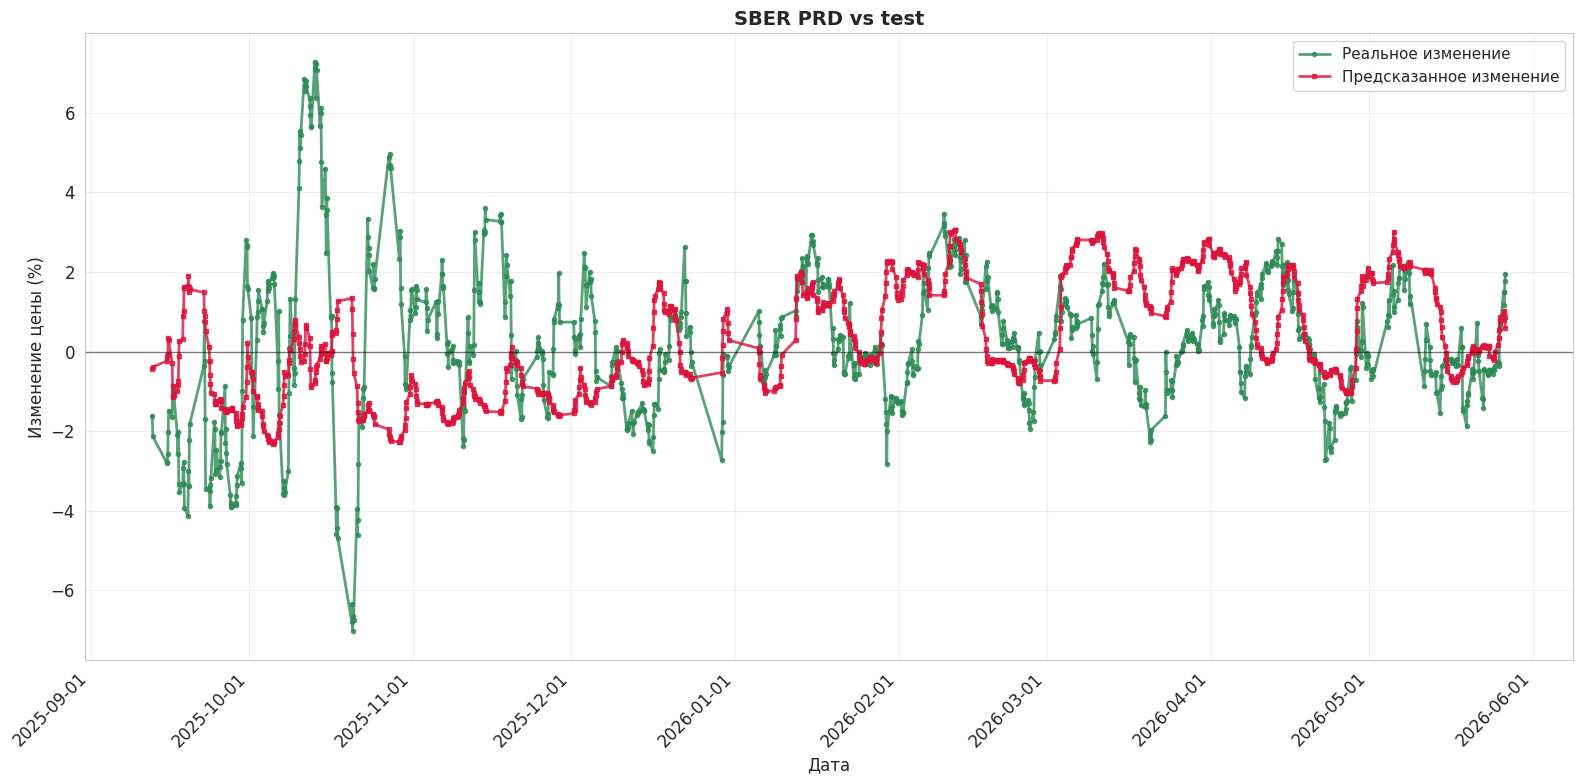

,model_mae,model_rmse,model_r2,model_direction_accuracy,baseline_mae,baseline_rmse,baseline_r2,baseline_direction_accuracy
0,1.671808,2.203226,-0.396483,0.567179,1.379391,1.877753,-0.014365,0.463532


In [32]:
prod_train_analyze(tcsg_summary_df)

## Сравнение лучших моделей

In [27]:
ticker_summaries = {
    'SBER': summary_df,
    'GAZP': gazp_summary_df,
    'LKOH': lkoh_summary_df,
    'ROSN': rosn_summary_df,
    'TCSG': tcsg_summary_df,
}

best_models_rows = []
for ticker_name, ticker_df in ticker_summaries.items():
    best_row_local = ticker_df.sort_values(['val_direction_accuracy', 'val_r2', 'val_rmse'], ascending=[False, False, True]).iloc[0]
    best_models_rows.append({
        'ticker': ticker_name,
        'run_name': best_row_local['run_name'],
        'run_id': best_row_local['run_id'],
        'sequence_length': best_row_local['sequence_length'],
        'hidden_size': best_row_local['hidden_size'],
        'num_layers': best_row_local['num_layers'],
        'dropout': best_row_local['dropout'],
        'learning_rate': best_row_local['learning_rate'],
        'val_mae': best_row_local['val_mae'],
        'val_rmse': best_row_local['val_rmse'],
        'val_r2': best_row_local['val_r2'],
        'val_direction_accuracy': best_row_local['val_direction_accuracy'],
        'test_mae': best_row_local['test_mae'],
        'test_rmse': best_row_local['test_rmse'],
        'test_r2': best_row_local['test_r2'],
        'test_direction_accuracy': best_row_local['test_direction_accuracy'],
    })

best_models_summary_df = pd.DataFrame(best_models_rows).sort_values('ticker').reset_index(drop=True)
best_models_summary_df.to_csv('best_models_summary.csv', index=False)
best_models_summary_df

,ticker,run_name,run_id,sequence_length,hidden_size,num_layers,dropout,learning_rate,val_mae,val_rmse,val_r2,val_direction_accuracy,test_mae,test_rmse,test_r2,test_direction_accuracy
0,GAZP,gazp_exp_36,79d79fd0148e49d99c50fe31d0bade58,16,16,2,0.25,0.0004,4.557162,5.826052,0.076478,0.703030,3.108729,3.888699,-0.760678,0.533333
1,LKOH,lkoh_exp_18,08da8cae5c004c3c85cffaa47b7d1e15,9,8,2,0.25,0.0004,2.885107,3.534187,0.017718,0.637019,3.387702,4.527504,-0.308832,0.476967
2,ROSN,rosn_exp_37,8ba1f479c1124deea1f5aa1736b8206b,16,32,1,0.10,0.0006,3.623157,4.880632,-0.186721,0.661818,4.623208,5.512166,-0.870755,0.428986
3,SBER,sber_exp_06,a332e883b56047b9911dd2be3599de5a,5,32,2,0.25,0.0004,2.487080,3.058997,-0.201638,0.553828,1.882019,2.458976,-0.738365,0.503824
4,TCSG,tcsg_exp_20,48799a1d69c3407e8e2feaab003a968e,9,16,2,0.25,0.0004,2.065471,2.602831,0.226310,0.694878,3.987175,5.063922,-0.081581,0.504440
